# INTRODUCTION
This notebook will be used to centered and crop the images (painting and celeb) in 256*256 images.

# Libraries

In [24]:
import os, sys, math, numpy as np
from PIL import Image, ImageOps
from tqdm import tqdm
import face_recognition as fr

SRC = "../../data/raw/paint_portrait"     # tes 3500 peintures
DST = "../../data/processed/32paint_portrait"     # sortie (tête+épaules, 64x64)
os.makedirs(DST, exist_ok=True)

In [27]:
def crop_head_shoulders(pil_img, scale=2.8, out=40, model="hog"):
    """
    1) détecte le visage le plus grand
    2) agrandit la bbox par 'scale' pour inclure front + épaules
    3) découpe au carré, puis redimensionne en out x out (LANCZOS)
    Fallback : center-crop carré si aucun visage détecté.
    """
    img = np.array(pil_img.convert("RGB"))
    # Détection des visages
    boxes = fr.face_locations(img, model=model)  # "hog" (CPU) | "cnn" (GPU, + lent mais + robuste)
    if not boxes:
        # Fallback: center-crop carré assez large (90% du côté court), puis resize
        w, h = pil_img.size
        s = int(min(w, h) * 0.90)
        left, top = (w - s)//2, (h - s)//2
        crop = pil_img.crop((left, top, left+s, top+s))
        return ImageOps.fit(crop, (out, out), method=Image.Resampling.LANCZOS, centering=(0.5, 0.5))

    # On garde le visage le plus grand (utile si plusieurs personnes)
    top, right, bottom, left = sorted(
        boxes, key=lambda b: (b[2]-b[0]) * (b[1]-b[3]), reverse=True
    )[0]

    # Centre et taille de la bbox visage
    cx, cy = (left + right) // 2, (top + bottom) // 2
    face_w, face_h = (right - left), (bottom - top)

    # Côté du carré = max(face_w, face_h) * scale  (2.6–3.2 conseillé)
    side = int(max(face_w, face_h) * float(scale))
    if side <= 0:
        side = max(pil_img.size)  # garde sécurité

    # Coordonnées du carré (centré sur le visage)
    x1, y1 = cx - side // 2, cy - side // 2
    x2, y2 = x1 + side, y1 + side

    # Clamp dans l'image
    W, H = pil_img.size
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)

    # Si la zone est minuscule (tableaux en pied, visage très petit) → fallback plus large
    if (x2 - x1) < 64 or (y2 - y1) < 64:
        s = int(min(W, H) * 0.90)
        left, top = (W - s)//2, (H - s)//2
        crop = pil_img.crop((left, top, left+s, top+s))
    else:
        crop = pil_img.crop((x1, y1, x2, y2))

    # Resize carré propre en out x out
    return ImageOps.fit(crop, (out, out), method=Image.Resampling.LANCZOS, centering=(0.5, 0.5))


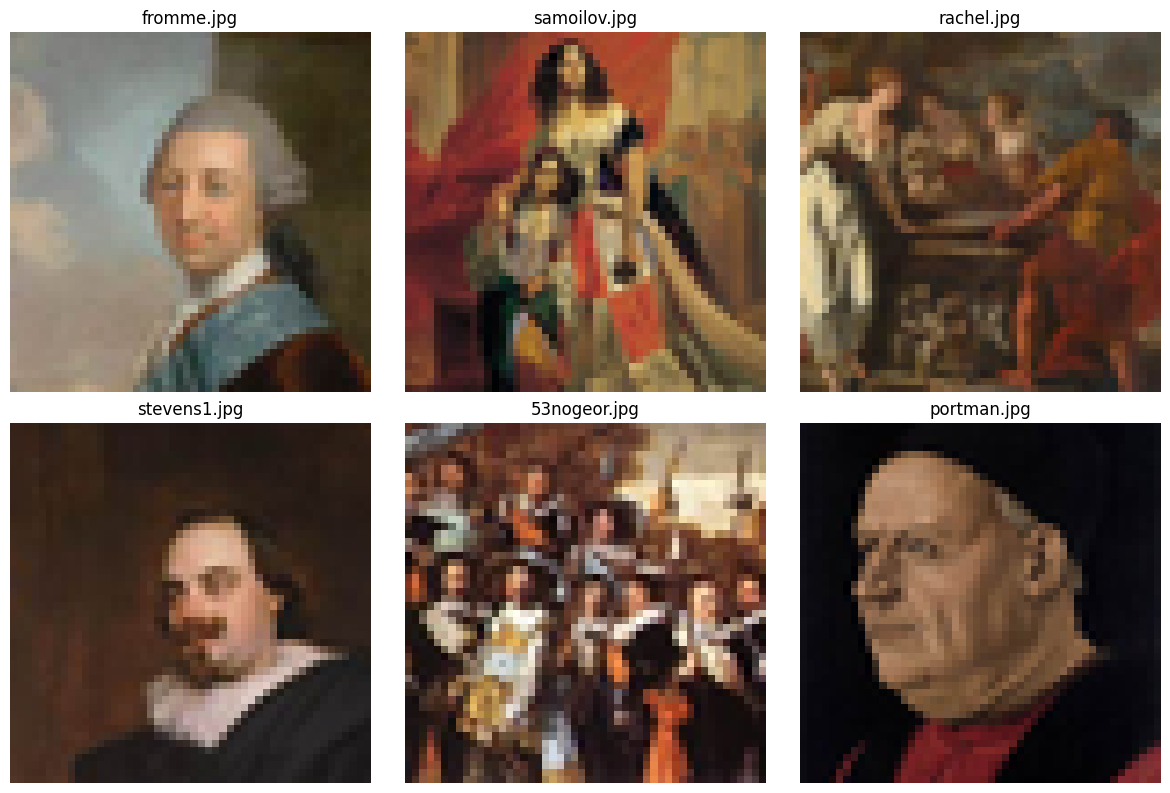

In [29]:
import random
import matplotlib.pyplot as plt

def preview_some(src_dir, n=6, **kwargs):
    files = [os.path.join(src_dir, f) for f in os.listdir(src_dir)
             if f.lower().endswith((".jpg",".jpeg",".png",".webp"))]
    random.shuffle(files)
    samples = files[:n]

    cols = min(n, 3)
    rows = math.ceil(n / cols)
    plt.figure(figsize=(4*cols, 4*rows))
    for i, p in enumerate(samples, 1):
        img = Image.open(p).convert("RGB")
        out = crop_head_shoulders(img, **kwargs)
        plt.subplot(rows, cols, i)
        plt.imshow(out); plt.axis("off"); plt.title(os.path.basename(p))
    plt.tight_layout(); plt.show()

# Essaie plusieurs échelles pour choisir ton cadrage
preview_some(SRC, n=6, scale=2.8, out=50, model="hog")


In [22]:
def process_dir(src, dst, scale=2.8, out=64, model="hog"):
    files = [os.path.join(src, f) for f in os.listdir(src)
             if f.lower().endswith((".jpg",".jpeg",".png",".webp"))]
    for p in tqdm(files, desc=f"Preprocess {os.path.basename(src)}"):
        try:
            img = Image.open(p).convert("RGB")
            out_img = crop_head_shoulders(img, scale=scale, out=out, model=model)
            # nom propre en .jpg
            name = os.path.splitext(os.path.basename(p))[0] + ".jpg"
            out_img.save(os.path.join(dst, name), quality=92)
        except Exception as e:
            print("skip:", p, e)

process_dir(SRC, DST, scale=2.8, out=64, model="hog")


Preprocess paint_portrait: 100%|██████████| 3592/3592 [03:37<00:00, 16.48it/s] 


In [23]:
SRC_A = "../../data/raw/img_celeb"     # tes 3500 peintures
DST_A = "../../data/processed/64img_celeb"         # sortie prête pour CycleGAN (domaine B)
os.makedirs(DST_A, exist_ok=True)
process_dir(SRC_A, DST_A, scale=2.8, out=64, model="hog")


Preprocess img_celeb: 100%|██████████| 8183/8183 [03:55<00:00, 34.74it/s] 


# CROPPING THE SCHOOL IMAGE in 64*64

In [ ]:
import os, sys
from io import BytesIO
from glob import glob
from tqdm import tqdm
import numpy as np
from PIL import Image, ImageOps, ImageFilter, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import os, glob, random
import matplotlib.pyplot as plt

In [30]:
# Source des données
french_train = "../../data/raw/french/train"
dutch_train = "../../data/raw/dutch/train"    
french_test = "../../data/raw/french/test"
dutch_test = "../../data/raw/dutch/test"

proces_french_train = "../../data/processed/french/train"
proces_dutch_train = "../../data/processed/dutch/train"
proces_french_test = "../../data/processed/french/test"
proces_dutch_test = "../../data/processed/dutch/test"
os.makedirs(proces_french_train, exist_ok=True)
os.makedirs(proces_dutch_train, exist_ok=True)
os.makedirs(proces_french_test, exist_ok=True)
os.makedirs(proces_dutch_test, exist_ok=True)

In [ ]:
for d in [proces_french_train, proces_dutch_train, proces_french_test, proces_dutch_test]:
    os.makedirs(d, exist_ok=True)

def list_images(root, exts=(".jpg",".jpeg",".png",".webp",".bmp",".tiff")):
    return [p for p in glob(os.path.join(root, "**"), recursive=True)
            if os.path.isfile(p) and p.lower().endswith(exts)]

def pad_to_square(img: Image.Image) -> Image.Image:
    """Letterbox: pad pour obtenir un carré, couleur = moyenne des bords."""
    img = ImageOps.exif_transpose(img).convert("RGB")
    w, h = img.size
    if w == h: 
        return img
    # couleur moyenne des bords
    arr = np.array(img)
    border_pixels = np.concatenate([
        arr[0, :, :], arr[-1, :, :], arr[:, 0, :], arr[:, -1, :]
    ], axis=0)
    mean_color = tuple([int(x) for x in border_pixels.mean(axis=0)])
    side = max(w, h)
    canvas = Image.new("RGB", (side, side), mean_color)
    canvas.paste(img, ((side - w)//2, (side - h)//2))
    return canvas

def crop_center_square(img: Image.Image) -> Image.Image:
    """Crop carré centré (garde la zone la plus informative en général)."""
    img = ImageOps.exif_transpose(img).convert("RGB")
    w, h = img.size
    s = min(w, h)
    left = (w - s) // 2
    top  = (h - s) // 2
    return img.crop((left, top, left + s, top + s))

def to_64(img: Image.Image, strategy="crop", unsharp=True) -> Image.Image:
    """
    strategy: "crop" (center-crop carré) ou "pad" (letterbox).
    unsharp: léger sharpen pour compenser le downscale.
    """
    if strategy == "pad":
        sq = pad_to_square(img)
    else:
        sq = crop_center_square(img)
    out = sq.resize((128, 128), resample=Image.Resampling.LANCZOS)
    if unsharp:
        out = out.filter(ImageFilter.UnsharpMask(radius=1, percent=80, threshold=3))
    return out

def process_dir(src_dir, dst_dir, strategy="crop", quality=95):
    files = list_images(src_dir)
    if not files:
        print(f"⚠️ Aucun fichier trouvé: {src_dir}")
        return
    os.makedirs(dst_dir, exist_ok=True)
    for p in tqdm(files, desc=f"{os.path.basename(src_dir)} -> 64x64 ({strategy})"):
        try:
            img = Image.open(p)
            out_img = to_64(img, strategy=strategy, unsharp=True)
            name = os.path.splitext(os.path.basename(p))[0] + ".jpg"
            out_img.save(os.path.join(dst_dir, name), format="JPEG", quality=quality, optimize=True)
        except Exception as e:
            print("skip:", p, e)

# --- Choisis ta stratégie: "crop" (recommandé) ou "pad" ---
STRATEGY = "crop"  # ou "pad"

# --- Lance le prétraitement ---
process_dir(french_train, proces_french_train, strategy=STRATEGY)
process_dir(dutch_train,  proces_dutch_train,  strategy=STRATEGY)
process_dir(french_test,  proces_french_test,  strategy=STRATEGY)
process_dir(dutch_test,   proces_dutch_test,   strategy=STRATEGY)

print("✅ Terminé.")


test -> 64x64 (crop): 100%|██████████| 322/322 [00:10<00:00, 29.99it/s]

✅ Terminé.


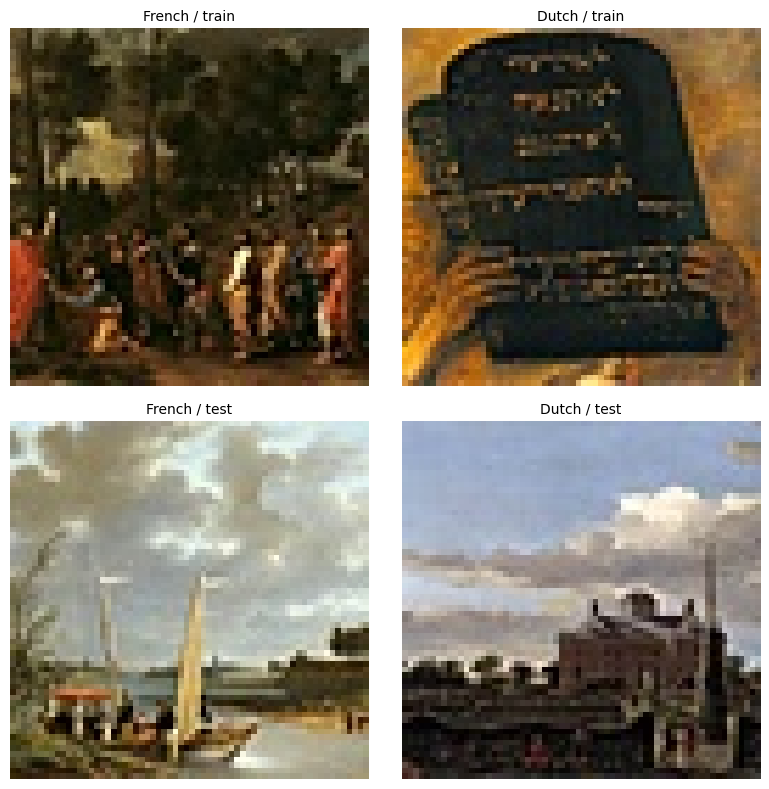

Fichiers affichés :
- French / train: ../../data/processed/french/train/1sacram1.jpg
- Dutch / train: ../../data/processed/dutch/train/24oldtet.jpg
- French / test: ../../data/processed/french/test/onaboat.jpg
- Dutch / test: ../../data/processed/dutch/test/huisten1.jpg


In [34]:
# Tes dossiers
french_train = "../../data/processed/french/train"
dutch_train  = "../../data/processed/dutch/train"
french_test  = "../../data/processed/french/test"
dutch_test   = "../../data/processed/dutch/test"

def pick_random_image(folder, exts=(".jpg",".jpeg",".png",".webp",".bmp",".tiff")):
    paths = [p for p in glob.glob(os.path.join(folder, "**"), recursive=True)
             if os.path.isfile(p) and p.lower().endswith(exts)]
    if not paths:
        raise RuntimeError(f"Aucune image trouvée dans: {folder}")
    return random.choice(paths)

# 1 image aléatoire par dossier
paths = {
    "French / train": pick_random_image(french_train),
    "Dutch / train":  pick_random_image(dutch_train),
    "French / test":  pick_random_image(french_test),
    "Dutch / test":   pick_random_image(dutch_test),
}

# Affichage 2×2
plt.figure(figsize=(8, 8))
for i, (title, p) in enumerate(paths.items(), 1):
    img = Image.open(p).convert("RGB")
    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(title, fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()

print("Fichiers affichés :")
for k, v in paths.items():
    print(f"- {k}: {v}")
